# Building response to earthquake

### Solving ordinary differential equation of dynamic motion involving mass, damping and spring in response to earthquake

![](https://github.com/TUDelft-MUDE/source-files/raw/main/file/1Ddynamic.png)


A building, considered here as a rigid mass, is subject to an earthquake. The foundation of the building, interacting with the ground, is represented by a spring and a dashpot (damper).

The dynamic motion of the building is defined by the following differential equation:

$$ k \left(u_b(t)-u_g(t) \right) + c \left(\frac{d u_b}{d t} - v_g(t) \right) + m \left(\frac{d^2 u_b}{d t^2} \right) = F $$

where:
*   $u_b$ = horizontal displacement of the building
*   $u_g$ = horizontal displacement of the ground (= earthquake outcrop motion)
*   $v_g$ = $du_g / dt$ = horizontal velocity of the ground
*   $t$ = time
*   $k$ = (shear) stiffness between the building foundation and the ground
*   $c$ = damping between the building foundation and the ground
*   $m$ = mass of the building
*   $F$ = external force acting on the building

In the remainder of this assignment we consider $F$ = 0

### Some initialisation:

In [148]:
import numpy as np
import matplotlib.pyplot as plt

k = 10000  # Stiffness
c = 20000 # Damping
m = 1000 # Mass

EDIT = 1

## Part 1: Reading and interpretion of the earthquake record

The earthquake outcrop motion is given in terms of acceleration $a_g$, velocity $v_g$ and displacement $u_g$ as time series at regular time intervals (0.005 seconds).
In the code cell below the earthquake data is read from the respective files and stored in corresponding arrays. Note that the unit of length in earthquake records is usually centimeter, so $a_g$ is given in $cm/s^2$, $v_g$ in $cm/s$ and $u_g$ in $cm$.

In [149]:
import os
from urllib.request import urlretrieve


def findfile(fname):
    if not os.path.isfile(fname):
        print(f"Downloading {fname}...")
        urlretrieve(
            "https://github.com/TUDelft-MUDE/source-files/raw/main/file/" + fname, fname
        )

In [150]:
# Download the data files (this may take some time if the server is busy)
findfile("Earthquake_acceleration.txt")
findfile("Earthquake_velocity.txt")
findfile("Earthquake_displacement.txt")

In [151]:
from itertools import islice


def readfile(filename):
    """Read data from file and return the data as a 1-D numpy array."""
    values = []
    with open(filename) as f:
        for line in islice(f, 3, None):  # Skip first 3 rows
            values.append(np.fromstring(line, sep=" "))
    return np.concatenate(values)


ag = readfile("Earthquake_acceleration.txt")
vg = readfile("Earthquake_velocity.txt")
ug = readfile("Earthquake_displacement.txt")

num = vg.shape[0]  # number of datapoints in the earthquake record
dt = 0.005  # time interval between subsequent data points
t = np.linspace(start=0, stop=dt * num, num=num)


### Plotting the earthquake ground velocity

<p>

>**Task 1.1**
>
>Write the Python code to plot the ground velocity $v_g$ as a function of time $t$ using the standard plotting facilities in Matplotlib.
>
</p>
</div>

In [152]:
plt.figure(figsize=(12, 4))

plt.show()


<Figure size 1200x400 with 0 Axes>

### Numerical differentiation and integration

As an exercise, we consider the earthquake ground velocity $v_g$ as the only given data, from which we calculate the ground acceleration $a_g$ by numerical differentiation and the ground displacement $u_g$ by numerical integration. 

### For the numerical differentiation we use the Forward Difference scheme:

><p>
>
>**Task 1.2**
>
>Formulate $a_g(t)$ = $\cfrac{d v_g(t)}{d t}$  by numerical differentiation according to the Forward Difference scheme, and write the necessary Python code.
>
></p>
</div>

In [153]:
# Forward Difference scheme to differentiate ground acceleration from given velocity
### YOUR CODE HERE ###
### YOUR CODE HERE ###
### YOUR CODE HERE ###


### For the numerical integration we use the Trapezoidal Rule:

><p>
>
>**Task 1.3**
>
>Formulate $u_g(t)$ = $\int{d v_g(t) d t}$  by numerical integration according to the Trapezoidal Rule, and write the necessary Python code.
>
></p>
></div>

In [154]:
# Trapezoidal Rule to integrate ground displacement from given velocity

### YOUR CODE HERE ###
### YOUR CODE HERE ###
### YOUR CODE HERE ###


### Comparing the calculated data with the original data

><p>
>
>**Task 1.4**
>
>Plot the calculated and original data in one plot to enable visual comparison. Do this for the acceleration $a_g$ as well as the displacement $u_g$ (in separate plots).
>
></p>
></div>

In [155]:
# Plotting ground acceleration

plt.figure(figsize=(12, 4))
### YOUR CODE HERE ###
### YOUR CODE HERE ###
### YOUR CODE HERE ###
plt.show()


<Figure size 1200x400 with 0 Axes>

In [156]:
# Plotting ground displacement

plt.figure(figsize=(12, 4))
### YOUR CODE HERE ###
### YOUR CODE HERE ###
### YOUR CODE HERE ###
plt.show()


<Figure size 1200x400 with 0 Axes>

>### Interpretation of the earthquake data
>
><p>
>
>**Task 1.5**
>
>Conclude on the accuracy of the calculated results.
>
>Are the results according to your expectation?
>For example, comment on the acceleration, velocity and displacement at the end of the recorded time series.
></p>
></div>


## Part 2: Numerical solution of the dynamic problem

Now, we proceed with the numerical solution of the above differential equation for the dynamic motion of the building $u_b$. Since the second derivative already requires two subsequent timesteps, we use the Central Difference scheme both for the first and second derivative to obtain maximum accuracy. Note that the ground acceleration is not used in the differential equation and the numerical solution; only the ground displacement and velocity! (Why?)


><p>
>
>**Task 2.1**
>
>Formulate the differential equation in a numerical scheme using the Central Difference scheme for the first and second derivative and by considering $u_b(t)$ = $u_b^i$ as the central point.
>
>Elaborate the numerical scheme such that the solution for the building displacement at the next time step $u_b(t + \Delta t)$ = $u_b^{i+1}$ is expressed explicitly in the other (known) components.
>
>Hint: Refer to next week's lecture or Section 1.6 in the book for an application involving the second derivative and verify that:
>$$ \frac{d^2 u_b}{d t^2} \approx \frac{u_b^{i+1} - 2 u_b^i + u_b^{i-1}}{\Delta t^2} $$
></p>
></div>


><p>
>
>**Task 2.2**
>
>How many initial conditions are required to solve the differential equation?
>
>Formulate these initial conditions for the numerical scheme.
>
></p>
></div>


### Implementation of the numerical solution
>
><p>
>
>**Task 2.3**
>
>Based on your elaboration above, write the necessary Python code to implement the numerical solution for the building displacement $u_b$ in time. Store the results in a list or (Numpy) array.
>
>Use a time step $\Delta t$ equal to the time interval of the earthquake data points.
>
></p>
></div>


In [157]:
def solution(k, c, m, num):
    """Solve the ODE for the building displacement in time
    
    Parameters
    ----------
    k : float
        Stiffness of the building
    c : float
        Damping of the building
    m : float
        Mass of the building
    num : int
        Number of time steps to solve for
    """
    u = np.zeros([num])  # Initial conditions at t=0 automatically satisfied

    for i in range(1, num - 1):
        teller_1 = 2 * dt**2 * (k * ug[i] + c * vg[i])
        teller_2 = (4 * m - 2 * k * dt**2) * u[i] + (c * dt - 2 * m) * u[i-1]
        
        teller_tot = teller_1 + teller_2

        breuk = (c * dt) + (2 * m)


        u[i+1] = teller_tot / breuk
    ### YOUR CODE HERE ###
    ### YOUR CODE HERE ###
    return u

ub = solution(k, c, m, num)
print(ub[99:101])

[-0.31440177 -0.31670193]



>
><p>
>
>As the implementation of this numerical solution is a bit trickier, you can use the code below to check if your output is correct:
>
></p>
></div>

In [158]:
# checks your output against the expected output

assert len(ub) == 7827, "number of timesteps is not correct."
assert ub[0] == 0, "Initial condition not satisfied."

assert np.allclose(ub[100], -0.09866151298075838), "Incorrect value at index 100."
assert np.allclose(ub[1000], 6.55694268229219), "Incorrect value at index 1000."
assert np.allclose(ub[-1], 1.9276415440472443), "Incorrect value at last index."

print("All tests passed!")

AssertionError: Incorrect value at index 100.

### Plotting the results
>
><p>
>
>**Task 2.4**
>
>Plot the results (building displacement $u_b$) as a function of time, together with the earthquake motion (ground displacement $u_g$).
>
></p>
></div>


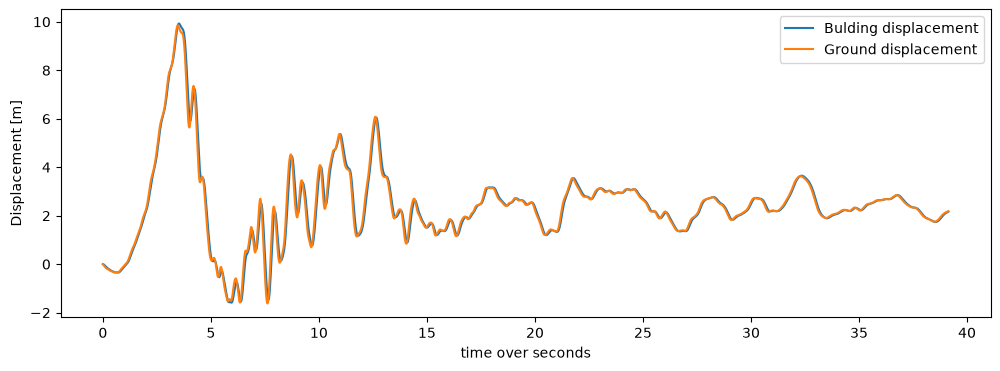

In [159]:
plt.figure(figsize=(12, 4))
plt.plot(t, ub, label = f'Bulding displacement')
plt.plot(t, ug, label = f'Ground displacement')
plt.legend()
plt.ylabel('Displacement [m]')
plt.xlabel('time over seconds')
### YOUR CODE HERE ###
### YOUR CODE HERE ###
plt.show()

><p>
>
>**Task 2.5**
>
>After interpretation of the previous results, you are requested to perform similar calculations for other parameter combinations. Vary $k$, $c$ and $m$ (factor 10 larger (and smaller), by editing the cell at the top of this notebook,  compared to their original value) and see how they influence the results. Think about whether your observations make physical sense. If 'oscillations' occur, try explaining them.
>
>Take notes on paper – you will need them later for the report.
></p>
></div>


> By Ronald Brinkgreve and Anna Störiko, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2025/credits.html).